In [15]:
%%writefile q1_solve.py
#!/usr/bin/env python3
"""
q1_solve.py

Implement ALL functions below.
Do NOT import sklearn.
"""

import numpy as np
from typing import List, Tuple


# -------------------------
# Utilities
# -------------------------
def add_bias(X: np.ndarray) -> np.ndarray:
    """
    Add bias (column of ones) as first column.
    See main.py for usage.
    """
    ones = np.ones((X.shape[0], 1), dtype=X.dtype)
    return np.hstack((ones, X))


def mse(y: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean squared error."""
    return float(np.mean((y - y_pred) ** 2))


def standardize_train(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Standardize features using training statistics.
    Returns standardized X, mean, and stddev.
    See main.py for usage.
    """
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Avoid division by zero if a feature is constant
    std_replaced = np.where(std == 0, 1.0, std)
    X_std = (X - mean) / std_replaced
    return X_std, mean, std


def standardize_apply(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """
    Apply training standardization.
    See main.py for usage.
    """
    std_replaced = np.where(std == 0, 1.0, std)
    return (X - mean) / std_replaced


# -------------------------
# Ridge Regression
# -------------------------
def ridge_regression_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """
    Closed-form ridge regression:
        (X^T X + λD) w = X^T y
    where D[0,0] = 0 (bias not regularized).
    """
    d = X.shape[1]
    D = np.eye(d)
    D[0, 0] = 0.0

    A = X.T @ X + lam * D
    b = X.T @ y

    return np.linalg.solve(A, b)


# -------------------------
# Cross-validation
# -------------------------
def k_fold_split(N: int, k: int) -> List[np.ndarray]:
    """
        k-fold split after shuffling
        Returns list of k arrays of indices.
    """
    indices = np.arange(N)
    np.random.shuffle(indices)
    return np.array_split(indices, k)


def ridge_cv(X: np.ndarray, y: np.ndarray, lam: float, k: int) -> float:
    """
    k-fold CV MSE for ridge.
    Use the k_fold_split function above to get the folds
    Use ridge_regression_closed_form to fit the model.
    Parameters:
        X: (N, D) training data
        y: (N,) training targets
        lam: regularization parameter
        k: number of folds
    Returns average MSE across folds.
    """
    folds = k_fold_split(X.shape[0], k)
    mses = []

    for i in range(k):
        val_indices = folds[i]
        train_indices = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train, y_train = X[train_indices], y[train_indices]
        X_val, y_val = X[val_indices], y[val_indices]

        w = ridge_regression_closed_form(X_train, y_train, lam)
        y_pred = X_val @ w
        mses.append(mse(y_val, y_pred))

    return float(np.mean(mses))


# -------------------------
# Hyperparameter search
# -------------------------
def grid_search_lambdas(
    X: np.ndarray, y: np.ndarray,
    lambdas: np.ndarray, k: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Evaluate each λ using CV.
    Parameters:
        X: (N, D) training data
        y: (N,) training targets
        lambdas: (M,) array of λ values to evaluate
        k: number of folds
    Returns:
        lambdas: (M,) same as input
        mses: (M,) average CV MSE for each λ
    """
    mses = np.zeros(lambdas.shape[0])
    for i, lam in enumerate(lambdas):
        mses[i] = ridge_cv(X, y, lam, k=k)
    return lambdas, mses


def random_search_lambdas(
    X: np.ndarray, y: np.ndarray,
    n_iter: int,
    low_exp: float,
    high_exp: float,
    k: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Sample λ = 10^u, where u ~ Uniform(low_exp, high_exp).
    Parameters:
        X: (N, D) training data
        y: (N,) training targets
        n_iter: number of λ values to sample
        low_exp: lower bound of exponent
        high_exp: upper bound of exponent
        k: number of folds
    Returns:
        lambdas: (n_iter,) sampled λ values
        mses: (n_iter,) average CV MSE for each λ
    """
    u = np.random.uniform(low_exp, high_exp, n_iter)
    lambdas = 10 ** u
    mses = np.zeros(n_iter)
    for i, lam in enumerate(lambdas):
        mses[i] = ridge_cv(X, y, lam, k=k)
    return lambdas, mses

Overwriting q1_solve.py


=== Ridge Regression Lab ===
OLS -> Train MSE: 9.0085, Test MSE: 8.4304
Grid Search best λ = 0.1, CV MSE = 9.8396
Random Search best λ = 1.25249, CV MSE = 9.8249
Best Ridge -> Test MSE: 8.3301
Saved cv_curve.png and metrics.json
=== DONE ===


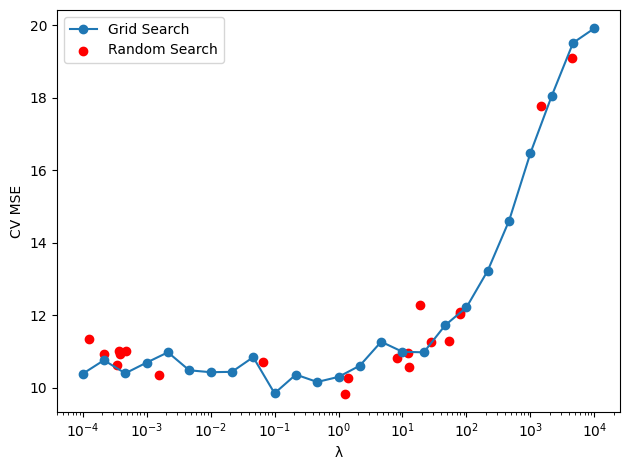

In [16]:
"""
q1_main.py

You MUST NOT edit this file
All implementations go into q1_solve.py

Usage:
    python q1_main.py
    python q1_main.py --verify-sklearn
"""

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import q1_solve as solve
import importlib # Import importlib to reload modules

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


def load_csv(path):
    data = np.loadtxt(path, delimiter=",")
    return data[:, :-1], data[:, -1]


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--verify-sklearn", action="store_true")
    # In a Colab environment, IPython/Jupyter passes extra arguments like -f
    # We need to tell argparse to ignore these for a clean parse.
    args, unknown = parser.parse_known_args()

    # Reload q1_solve to ensure the latest changes are applied
    importlib.reload(solve)

    print("=== Ridge Regression Lab ===")

    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    X_train_raw, y_train = load_csv("q1_train.csv")
    X_test_raw, y_test = load_csv("q1_test.csv")

    # --------------------------------------------------
    # Preprocessing
    # --------------------------------------------------
    X_train_std, mu, sigma = solve.standardize_train(X_train_raw)
    X_test_std = solve.standardize_apply(X_test_raw, mu, sigma)

    X_train = solve.add_bias(X_train_std)
    X_test = solve.add_bias(X_test_std)

    # --------------------------------------------------
    # OLS baseline
    # --------------------------------------------------
    w_ols = solve.ridge_regression_closed_form(X_train, y_train, lam=0.0)
    train_mse_ols = solve.mse(y_train, X_train @ w_ols)
    test_mse_ols = solve.mse(y_test, X_test @ w_ols)

    print(f"OLS -> Train MSE: {train_mse_ols:.4f}, Test MSE: {test_mse_ols:.4f}")

    # --------------------------------------------------
    # Lambda ranges
    # --------------------------------------------------
    lambdas_grid = np.logspace(-4, 4, 25)

    # --------------------------------------------------
    # Grid Search
    # --------------------------------------------------
    grid_lams, grid_mses = solve.grid_search_lambdas(X_train, y_train, lambdas_grid, k=5)
    best_idx_grid = int(np.argmin(grid_mses))
    best_lambda_grid = float(grid_lams[best_idx_grid])

    print(f"Grid Search best λ = {best_lambda_grid:.6g}, CV MSE = {grid_mses[best_idx_grid]:.4f}")

    # --------------------------------------------------
    # Random Search
    # --------------------------------------------------
    rand_lams, rand_mses = solve.random_search_lambdas(X_train, y_train, n_iter=20, low_exp=-4, high_exp=4, k=5)
    best_idx_rand = int(np.argmin(rand_mses))
    best_lambda_rand = float(rand_lams[best_idx_rand])

    print(f"Random Search best λ = {best_lambda_rand:.6g}, CV MSE = {rand_mses[best_idx_rand]:.4f}")

    # --------------------------------------------------
    # Evaluate best (grid) model
    # --------------------------------------------------
    w_best = solve.ridge_regression_closed_form(X_train, y_train, best_lambda_grid)
    test_mse_best = solve.mse(y_test, X_test @ w_best)

    print(f"Best Ridge -> Test MSE: {test_mse_best:.4f}")

    # --------------------------------------------------
    # Optional sklearn verification
    # --------------------------------------------------
    if args.verify_sklearn:
        print("Running sklearn sanity check...")
        kf = KFold(n_splits=5, shuffle=True)
        sk_mses = []
        for tr, va in kf.split(X_train):
            model = Ridge(alpha=best_lambda_grid, fit_intercept=False)
            model.fit(X_train[tr], y_train[tr])
            sk_mses.append(
                mean_squared_error(y_train[va], model.predict(X_train[va]))
            )
        print(f"[sklearn] CV MSE ≈ {np.mean(sk_mses):.4f}")

    # --------------------------------------------------
    # Plots
    # --------------------------------------------------
    plt.figure()
    plt.semilogx(grid_lams, grid_mses, marker="o", label="Grid Search")
    plt.scatter(rand_lams, rand_mses, c="red", label="Random Search")
    plt.xlabel("λ")
    plt.ylabel("CV MSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig("cv_curve.png")

    # --------------------------------------------------
    # Save metrics
    # --------------------------------------------------
    metrics = {
        "ols_test_mse": test_mse_ols,
        "best_lambda_grid": best_lambda_grid,
        "best_lambda_random": best_lambda_rand,
        "best_ridge_test_mse": test_mse_best
    }

    with open("metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print("Saved cv_curve.png and metrics.json")
    print("=== DONE ===")


if __name__ == "__main__":
    main()